## **Supervised Model I – Logistic Regression**

Expectation: this model may not perform very well, as it is a simple linear model that can only learn linear decision boundaries.

It can be used as a **simple baseline** to compare other models against

**Load Training Dataframe**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from feature_pipeline import load_data, exclude_test_users, compute_item_stats, build_features, get_feature_columns, get_test_labels
from analysis import model_metrics, plot_score_distribution, plot_roc_curve, plot_pr_curve, plot_confusion_matrix


def create_feature_df_trial(train_data, test_data):
    """Trial phase: test users are a subset of training, so we exclude them to prevent leakage
    and retrieve their labels from the training labels."""
    print(f"LOADING DATA USING FEATURE PIPELINE (TRIAL PHASE)...")
    XX_train, yy_all, XX_test = load_data(train_data, test_data)

    # Remove test users from training to prevent leakage
    XX_train, yy = exclude_test_users(XX_train, yy_all, XX_test)

    # Freeze item stats from training users only
    item_stats = compute_item_stats(XX_train)

    # Training features
    user_df = build_features(XX_train, item_stats).merge(yy, on="user")
    feature_cols = get_feature_columns(user_df)
    X_features = user_df[feature_cols].values
    y_labels = user_df["label"].values

    # Test features (using frozen training item stats)
    test_df = build_features(XX_test, item_stats)
    X_test = test_df[feature_cols].values

    # Ground truth labels for test users (available because they overlap with training)
    test_labels = test_df[["user"]].merge(yy_all, on="user")["label"].values

    print(f"Train: {X_features.shape[0]} users, {len(feature_cols)} features")
    print(f"Test:  {X_test.shape[0]} users ({int(test_labels.sum())} anomalous)")

    return X_features, y_labels, X_test, feature_cols, test_labels


def create_feature_df(train_data, test_data, labeled_test_data=None):
    """Competition phase: test users are unseen. Optionally pass the labeled test file
    (released after each week) to get ground-truth labels for local evaluation."""
    print(f"LOADING DATA USING FEATURE PIPELINE...")
    XX_train, yy_all, XX_test = load_data(train_data, test_data)

    # Freeze item stats from training users only
    item_stats = compute_item_stats(XX_train)

    # Training features
    user_df = build_features(XX_train, item_stats).merge(yy_all, on="user")
    feature_cols = get_feature_columns(user_df)
    X_features = user_df[feature_cols].values
    y_labels = user_df["label"].values

    # Test features (using frozen training item stats — prevent data leakage)
    test_df = build_features(XX_test, item_stats)
    X_test = test_df[feature_cols].values

    print(f"Train: {X_features.shape[0]} users, {len(feature_cols)} features")
    print(f"Test:  {X_test.shape[0]} users")

    # If labeled test file is provided, extract ground-truth labels for local evaluation
    if labeled_test_data is not None:
        test_labels = get_test_labels(labeled_test_data, test_df)
        print(f"Test labels loaded: {len(test_labels)} users ({int(test_labels.sum())} anomalous)")
        return X_features, y_labels, X_test, feature_cols, test_labels

    return X_features, y_labels, X_test, feature_cols

**Train the model**

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

def train_model(X_features, y_labels, regularization_strength = 1.0):
    print(f"\nTRAINING LOGISTIC REGRESSION MODEL WITH regularization_strength = {regularization_strength}...")

    # Tunable parameters:
    regularization_strength = regularization_strength

    # Random seed for reproducibility
    RANDOM_SEED = 42

    # Logistic Regression is sensitive to feature scales, so we need to standardize the data
    lr_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(
            class_weight="balanced",    # handles imbalanced classes
            max_iter=1000,              # ensure convergence
            C=regularization_strength,  # regularization strength (lower = more regularization)
            random_state=RANDOM_SEED
        ))
    ])

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

    lr_scores = []
    lr_precision = []
    lr_recall = []
    lr_f1 = []

    for train_idx, val_idx in skf.split(X_features, y_labels):
        X_train, X_val = X_features[train_idx], X_features[val_idx]
        y_train, y_val = y_labels[train_idx], y_labels[val_idx]

        lr_pipeline.fit(X_train, y_train)
        y_prob = lr_pipeline.predict_proba(X_val)[:, 1]  # P(anomalous)
        y_pred = lr_pipeline.predict(X_val) # Predicted classes

        lr_scores.append(roc_auc_score(y_val, y_prob))
        lr_precision.append(precision_score(y_val, y_pred))
        lr_recall.append(recall_score(y_val, y_pred))
        lr_f1.append(f1_score(y_val, y_pred))

    print(f"Logistic Regression AUC: {np.mean(lr_scores):.4f} ± {np.std(lr_scores):.4f}")
    print(f"Logistic Regression Precision: {np.mean(lr_precision):.4f} ± {np.std(lr_precision):.4f}")
    print(f"Logistic Regression Recall: {np.mean(lr_recall):.4f} ± {np.std(lr_recall):.4f}")
    print(f"Logistic Regression F1 Score: {np.mean(lr_f1):.4f} ± {np.std(lr_f1):.4f}")

    return lr_pipeline

**Inspect coefficients**

In [3]:
import matplotlib.pyplot as plt

def inspect_coefficients(lr_pipeline, X_features, y_labels, feature_cols):
    # Train on full data for inspection
    lr_pipeline.fit(X_features, y_labels)

    # Get coefficients (higher absolute value = more influential)
    coefs = pd.Series(
        lr_pipeline.named_steps["lr"].coef_[0],
        index=feature_cols
    ).sort_values()

    # Visualise coefficients
    fig, ax = plt.subplots(figsize=(8, 6))
    coefs.plot.barh(ax=ax)
    ax.set_title("Logistic Regression Coefficients")
    ax.axvline(x=0, color="black", linewidth=0.5)
    plt.tight_layout()
    plt.show()

**Test Logistic Regression model**

In [4]:
def test_model(lr_pipeline, X_test, submission_file_name = "logistic_regression.npz"):
    print(f"\nPREDICTING WITH LOGISTIC REGRESSION MODEL...")
    # Predict scores on test data (X_test built from feature_pipeline with frozen item stats)
    y_score_lr = lr_pipeline.predict_proba(X_test)[:, 1]

    # Save as submission.npz
    np.savez(submission_file_name, predictions=y_score_lr)
    print(f"Predictions saved to {submission_file_name}")

**Collate data across different phases**

## **Trial Phase**

In [5]:
# Load and compute feature df (trial: test users are a subset of training)
X_features, y_labels, X_test, feature_cols, test_labels = create_feature_df_trial("data/training_batch_with_labels.npz", "data/subset_training_batch.npz")
# Train the model
lr_pipeline = train_model(X_features, y_labels, 1.0)

LOADING DATA USING FEATURE PIPELINE (TRIAL PHASE)...
Excluded 220 overlapping users from training (1100 → 880 users)
Train: 880 users, 24 features
Test:  220 users (18 anomalous)

TRAINING LOGISTIC REGRESSION MODEL WITH regularization_strength = 1.0...
Logistic Regression AUC: 0.8491 ± 0.0362
Logistic Regression Precision: 0.2912 ± 0.0355
Logistic Regression Recall: 0.7456 ± 0.0916
Logistic Regression F1 Score: 0.4179 ± 0.0465


Based on the training with regularization strength = 1.0, the model performs reasonably well with a mean AUC score of 0.87. We can move on to train the model on the full dataset. ‼️ draw insight from the scores calculated and what can be inferred about the model

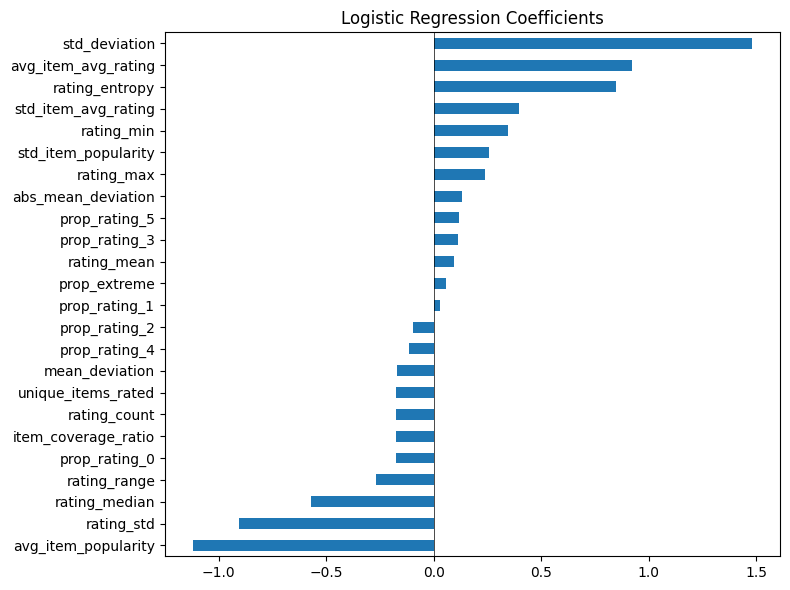

In [6]:
inspect_coefficients(lr_pipeline, X_features, y_labels, feature_cols)

Positive coefficients push toward "anomalous," while negative ones push toward "normal."

# Logistic Regression
# AUC:       0.9018
# Precision: 0.6471
# Recall:    0.6111
# F1 Score:  0.6286


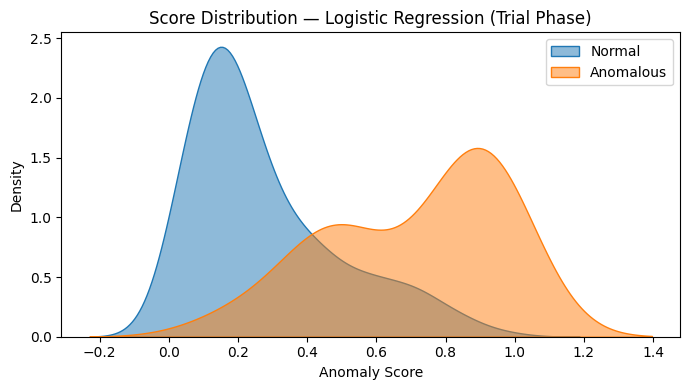

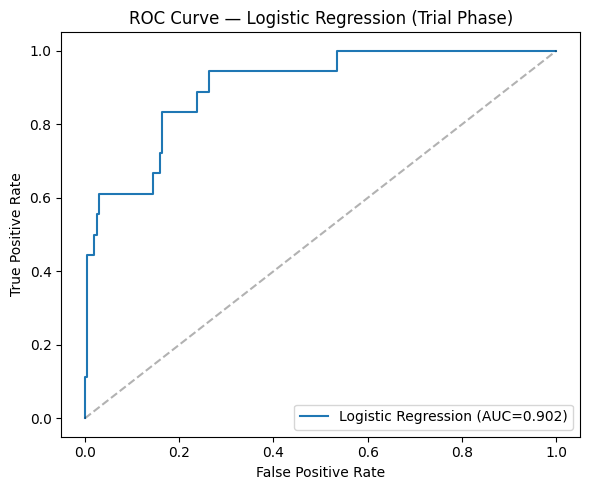

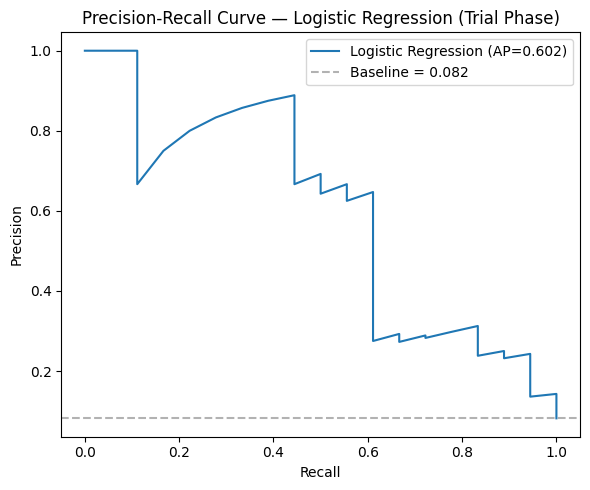

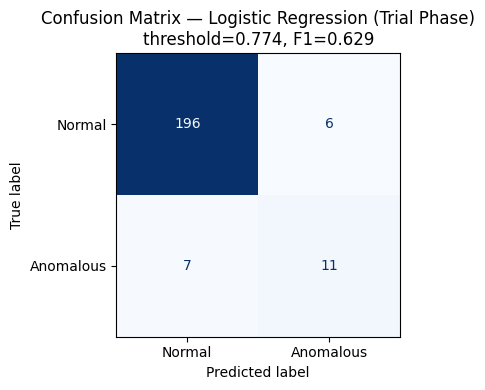

In [ ]:
# Evaluate the model against known labels
y_scores = lr_pipeline.predict_proba(X_test)[:, 1]
model_metrics(test_labels, y_scores, "Logistic Regression")

# Visualise performance
plot_score_distribution(test_labels, y_scores, "Logistic Regression", "Trial Phase")
plot_roc_curve(test_labels, y_scores, "Logistic Regression", "Trial Phase")
plot_pr_curve(test_labels, y_scores, "Logistic Regression", "Trial Phase")
plot_confusion_matrix(test_labels, y_scores, "Logistic Regression", "Trial Phase")

An AUC score of 0.9018 shows that the model has strong class separation ability. However, the low precision score (28.26%) means that most of the flagged cases are false positives. The model is aggressive in labeling positives to avoid missing any anomalies.

## **Phase 1: First Batch**

LOADING DATA USING FEATURE PIPELINE...
Train: 1100 users, 24 features
Test:  1100 users
Test labels loaded: 1100 users (100 anomalous)

TRAINING LOGISTIC REGRESSION MODEL WITH regularization_strength = 1.0...
Logistic Regression AUC: 0.8699 ± 0.0176
Logistic Regression Precision: 0.3050 ± 0.0340
Logistic Regression Recall: 0.7600 ± 0.0490
Logistic Regression F1 Score: 0.4331 ± 0.0278


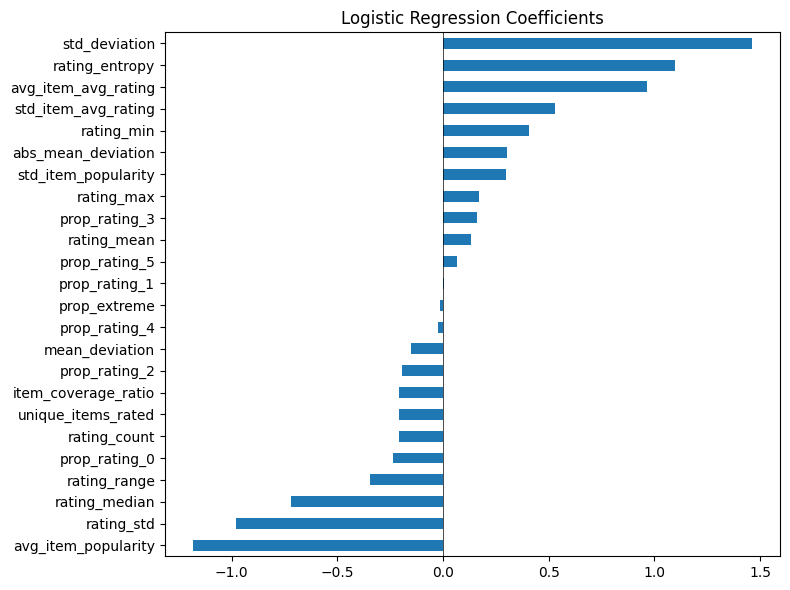

# Logistic Regression
# AUC:       0.8551
# Precision: 0.6471
# Recall:    0.4400
# F1 Score:  0.5238


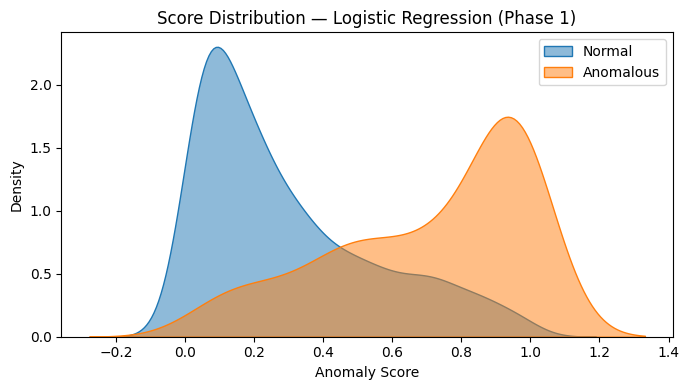

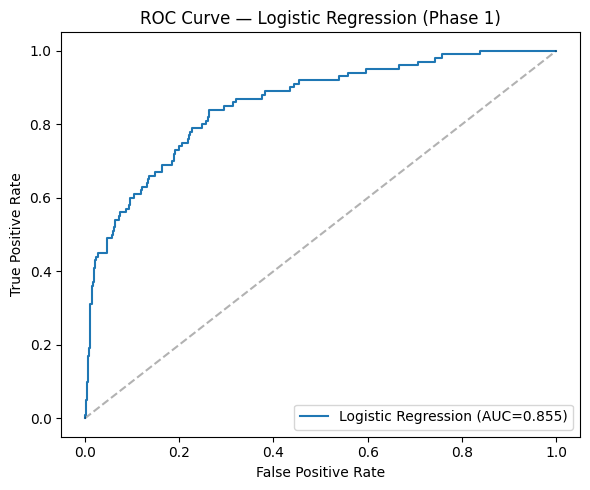

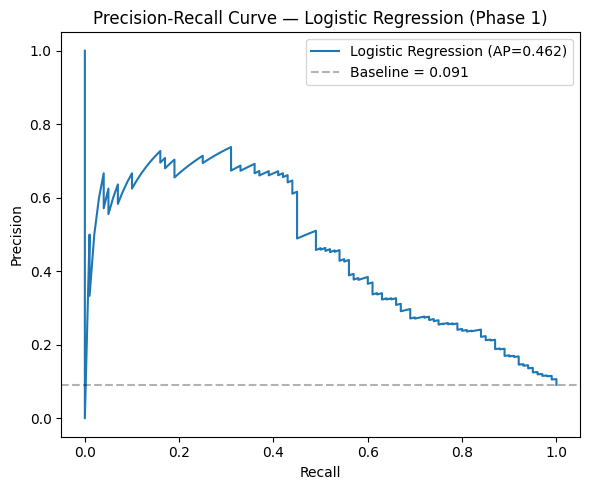

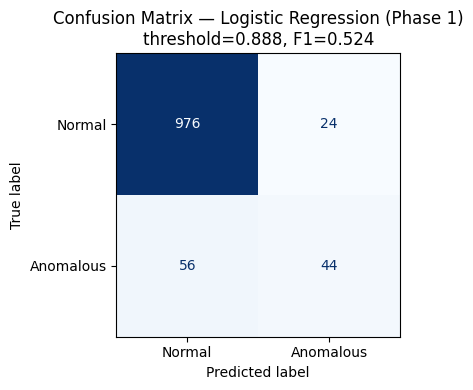

In [ ]:
# Load and compute feature df 
X_features_p1, y_labels_p1, X_test_p1, feature_cols_p1, test_labels_p1 = create_feature_df(
    "data/training_batch_with_labels.npz", "data/first_batch.npz", "data/first_batch_with_labels.npz"
)
# Train the model
lr_pipeline_p1 = train_model(X_features_p1, y_labels_p1, 1.0)
inspect_coefficients(lr_pipeline_p1, X_features_p1, y_labels_p1, feature_cols_p1)

# Evaluate the model against known labels
y_scores_p1 = lr_pipeline_p1.predict_proba(X_test_p1)[:, 1]
model_metrics(test_labels_p1, y_scores_p1, "Logistic Regression")

# Visualise performance
plot_score_distribution(test_labels_p1, y_scores_p1, "Logistic Regression", "Phase 1")
plot_roc_curve(test_labels_p1, y_scores_p1, "Logistic Regression", "Phase 1")
plot_pr_curve(test_labels_p1, y_scores_p1, "Logistic Regression", "Phase 1")
plot_confusion_matrix(test_labels_p1, y_scores_p1, "Logistic Regression", "Phase 1")